# Day 1 · Session 4 — Multimodal AI

## Images · Documents · Audio · Video · Fusion

This notebook supports the theory session on **Multimodal AI**.

It is intentionally kept **clean, simple, classroom-friendly, and reliable**.

### What you will experience

1. How a multimodal model understands an image
2. How prompts change visual reasoning
3. How a document page can be converted into useful information
4. How audio transcription fits into a multimodal workflow
5. How video understanding can be approximated using key frames
6. How text + image + structured output can support practical teaching workflows

### Big idea

> Earlier AI systems usually worked with one type of data at a time.  
> Multimodal AI can combine text, images, documents, audio, and video-like frames in one workflow.

### AI Engineering mindset

We are not using multimodal AI just because it is exciting. We use it when the problem genuinely requires information beyond text.

## 0. Environment setup

This notebook uses:

- `openai` for model calls
- `Pillow` for creating local demo images
- `matplotlib` for creating a simple chart
- `python-dotenv` for reading `.env` files

If packages are missing, run the installation cell below once.

In [1]:
# Run this cell only if the packages are not already installed.
# It is safe to run in most notebook environments.

import sys
import subprocess
import importlib.util

required_packages = [
    ("openai", "openai"),
    ("PIL", "pillow"),
    ("matplotlib", "matplotlib"),
    ("dotenv", "python-dotenv"),
]

missing = [pip_name for import_name, pip_name in required_packages if importlib.util.find_spec(import_name) is None]

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
else:
    print("All required packages are already installed.")

All required packages are already installed.


## 1. Imports and configuration

For live API calls, set your OpenAI API key in one of these ways:

### Option A — Environment variable

```bash
export OPENAI_API_KEY="your_api_key_here"
```

### Option B — `.env` file in the same folder

```text
OPENAI_API_KEY=your_api_key_here
```

The notebook will not fail if the key is missing. It will simply skip live API calls and print a clear message.

In [2]:
import os
import json
import base64
import textwrap
from pathlib import Path
from typing import Any, Dict, List, Optional

from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()

try:
    from openai import OpenAI
except Exception as e:
    OpenAI = None
    print("OpenAI SDK could not be imported:", e)

ASSET_DIR = Path("session4_assets")
ASSET_DIR.mkdir(exist_ok=True)

# Keep models configurable for future changes.
# Use a current multimodal model available in your OpenAI account.
VISION_MODEL = os.getenv("OPENAI_VISION_MODEL", "gpt-4o-mini")
TEXT_MODEL = os.getenv("OPENAI_TEXT_MODEL", "gpt-4o-mini")
TRANSCRIBE_MODEL = os.getenv("OPENAI_TRANSCRIBE_MODEL", "gpt-4o-transcribe")

api_key = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=api_key) if (OpenAI is not None and api_key) else None

print("Asset folder:", ASSET_DIR.resolve())
print("Vision model:", VISION_MODEL)
print("Text model:", TEXT_MODEL)
print("OpenAI client ready:", client is not None)

if client is None:
    print("\nLive OpenAI calls will be skipped until OPENAI_API_KEY is configured.")

Asset folder: /Users/suresh/Projects/teaching/fdp-llm-agentic-ai/day1-llm-foundations/session4_assets
Vision model: gpt-4o-mini
Text model: gpt-4o-mini
OpenAI client ready: True


## 2. Helper functions

We avoid external image URLs in this FDP notebook.

Why?

External URLs may fail because of redirects, bot protection, rate limits, or temporary CDN issues. For classroom reliability, we use **local images converted to Base64 data URLs**.

In [3]:
def image_to_data_url(image_path: str | Path) -> str:
    """Convert a local image into a Base64 data URL suitable for OpenAI image input."""
    image_path = Path(image_path)
    suffix = image_path.suffix.lower().replace(".", "")
    mime = "jpeg" if suffix in {"jpg", "jpeg"} else "png"
    encoded = base64.b64encode(image_path.read_bytes()).decode("utf-8")
    return f"data:image/{mime};base64,{encoded}"


def print_box(title: str, content: str, width: int = 100) -> None:
    """Pretty-print long model responses."""
    print("\n" + "=" * width)
    print(title)
    print("=" * width)
    print(textwrap.fill(content, width=width))


def call_responses_api(
    *,
    model: str,
    instructions: str,
    user_content: List[Dict[str, Any]],
    max_output_tokens: int = 700,
    temperature: float = 0.2,
) -> Optional[str]:
    """Call the OpenAI Responses API. Skip safely when the API key is not configured."""
    if client is None:
        print("Skipped live API call: OPENAI_API_KEY is not configured.")
        return None

    response = client.responses.create(
        model=model,
        instructions=instructions,
        input=[{"role": "user", "content": user_content}],
        max_output_tokens=max_output_tokens,
        temperature=temperature,
    )
    return response.output_text


def extract_json(text: str) -> Dict[str, Any]:
    """Best-effort JSON extraction for classroom demos."""
    if text is None:
        return {}

    cleaned = text.strip()

    # Remove markdown fences if the model returns ```json ... ```
    if cleaned.startswith("```"):
        cleaned = cleaned.strip("`")
        if cleaned.lower().startswith("json"):
            cleaned = cleaned[4:].strip()

    try:
        return json.loads(cleaned)
    except Exception:
        pass

    # Fallback: try to extract the first JSON object from the response.
    start = cleaned.find("{")
    end = cleaned.rfind("}")
    if start != -1 and end != -1 and end > start:
        return json.loads(cleaned[start : end + 1])

    raise ValueError("Could not parse JSON from model response.")

## 3. Create local demo assets

To make the notebook reliable, we generate simple images locally.

This also makes the notebook portable across Windows, macOS, and Linux.

In [4]:
# Demo Image 1: Classroom scene
classroom_img = ASSET_DIR / "classroom_scene.png"

img = Image.new("RGB", (900, 560), color=(245, 248, 255))
draw = ImageDraw.Draw(img)

# Board
board = (80, 60, 820, 220)
draw.rectangle(board, fill=(25, 75, 70), outline=(20, 50, 50), width=4)
draw.text((115, 95), "AI Engineering FDP", fill="white")
draw.text((115, 135), "Problem  →  Data  →  Model  →  Evaluation", fill="white")
draw.text((115, 175), "Multimodal AI: Text + Image + Audio", fill=(220, 255, 220))

# Lecturer
lecturer_x, lecturer_y = 135, 360
draw.ellipse((lecturer_x-25, lecturer_y-90, lecturer_x+25, lecturer_y-40), fill=(255, 210, 170), outline="black")
draw.rectangle((lecturer_x-22, lecturer_y-40, lecturer_x+22, lecturer_y+60), fill=(70, 115, 200), outline="black")
draw.line((lecturer_x+22, lecturer_y-10, lecturer_x+90, lecturer_y-75), fill="black", width=4)

# Students
for x in [330, 470, 610, 750]:
    draw.ellipse((x-24, 325, x+24, 373), fill=(255, 215, 180), outline="black")
    draw.rectangle((x-34, 374, x+34, 455), fill=(130, 150, 210), outline="black")
    draw.rectangle((x-60, 455, x+60, 490), fill=(200, 210, 230), outline="black")
    draw.rectangle((x-42, 418, x+42, 452), fill=(240, 240, 250), outline="gray")

# Icons: image, document, audio
icon_y = 255
for i, label in enumerate(["Image", "Document", "Audio"]):
    x = 270 + i * 160
    draw.rounded_rectangle((x, icon_y, x+100, icon_y+70), radius=12, fill=(230, 240, 255), outline=(70, 110, 200), width=3)
    draw.text((x+22, icon_y+25), label, fill=(20, 40, 90))

img.save(classroom_img)
classroom_img

PosixPath('session4_assets/classroom_scene.png')

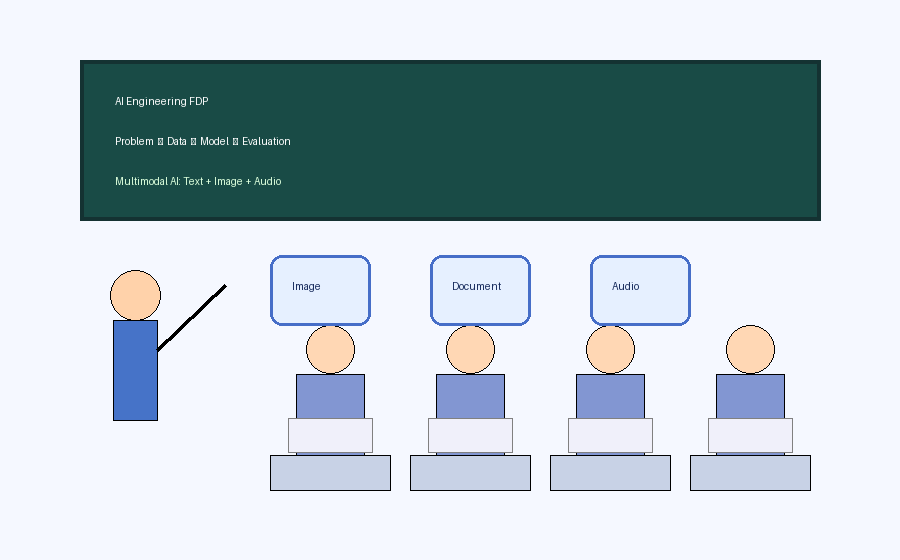

In [5]:
# Display the generated classroom image
Image.open(classroom_img)

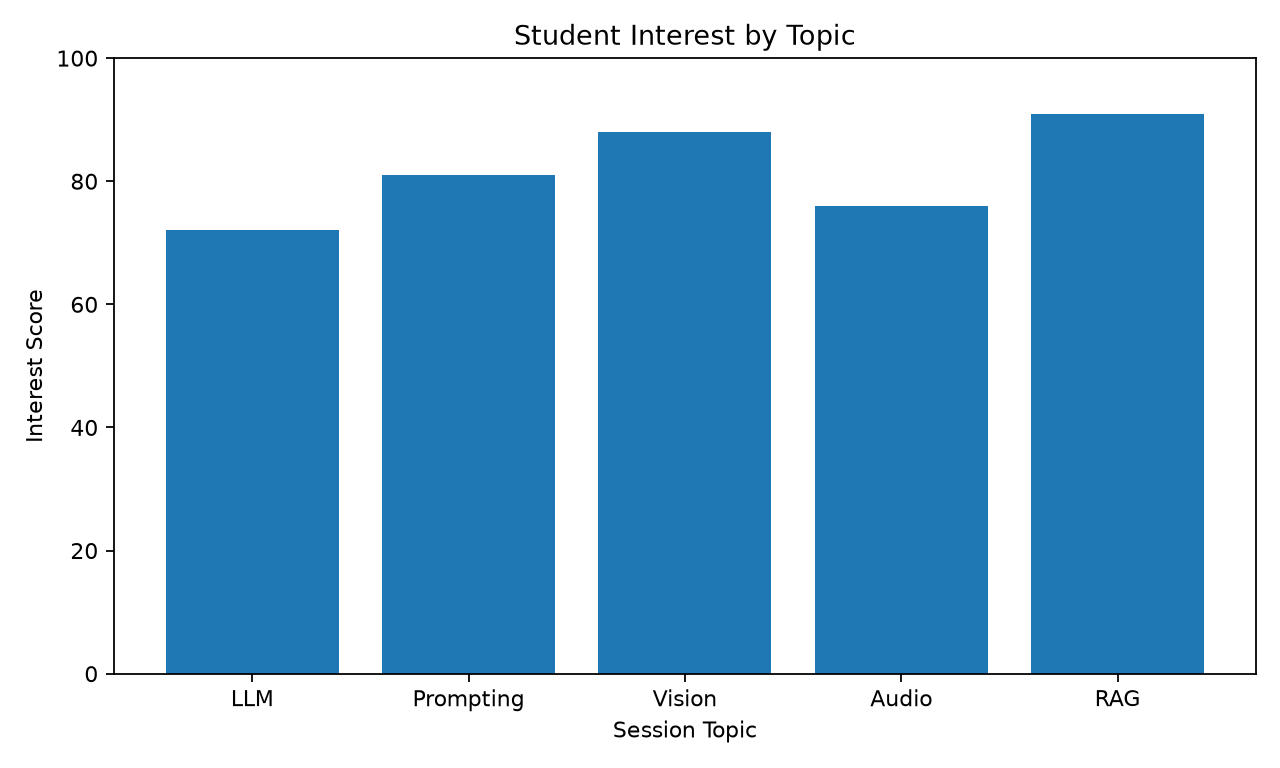

In [6]:
# Demo Image 2: Simple chart
chart_img = ASSET_DIR / "student_feedback_chart.png"

sessions = ["LLM", "Prompting", "Vision", "Audio", "RAG"]
scores = [72, 81, 88, 76, 91]

plt.figure(figsize=(8, 4.8))
plt.bar(sessions, scores)
plt.title("Student Interest by Topic")
plt.xlabel("Session Topic")
plt.ylabel("Interest Score")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(chart_img, dpi=160)
plt.close()

Image.open(chart_img)

In [7]:
# Demo Image 3: Document-like page
report_img = ASSET_DIR / "sample_report_page.png"

page = Image.new("RGB", (900, 1200), color="white")
d = ImageDraw.Draw(page)

left = 70
y = 70
d.text((left, y), "Faculty AI Readiness Report", fill="black")
y += 60
d.line((left, y, 830, y), fill="black", width=2)
y += 50

paragraphs = [
    "Context: A department wants to introduce AI-assisted learning activities for faculty and students.",
    "Observation 1: Faculty members are comfortable with basic AI tools, but need more confidence in designing AI workflows.",
    "Observation 2: Participants prefer practical demonstrations over tool-heavy lectures.",
    "Recommendation: Start with problem framing, then introduce prompt engineering, RAG, and simple AI agents.",
    "Risk: Overuse of AI without validation may lead to inaccurate or misleading teaching content.",
    "Action: Use AI outputs as drafts, review them carefully, and document limitations.",
]

for p in paragraphs:
    wrapped = textwrap.wrap(p, width=82)
    for line in wrapped:
        d.text((left, y), line, fill="black")
        y += 32
    y += 18

# Small table
start_y = y + 20
d.rectangle((left, start_y, 830, start_y + 180), outline="black", width=2)
for row in range(1, 4):
    d.line((left, start_y + row * 45, 830, start_y + row * 45), fill="black", width=1)
d.line((370, start_y, 370, start_y + 180), fill="black", width=1)

table_rows = [
    ("Area", "Suggested AI Approach"),
    ("Lecture preparation", "LLM + human review"),
    ("Document Q&A", "RAG"),
    ("Workflow automation", "AI agent with tools"),
]
for idx, (a, b) in enumerate(table_rows):
    yy = start_y + 12 + idx * 45
    d.text((left + 18, yy), a, fill="black")
    d.text((390, yy), b, fill="black")

report_img_path = report_img
page.save(report_img_path)
report_img_path

PosixPath('session4_assets/sample_report_page.png')

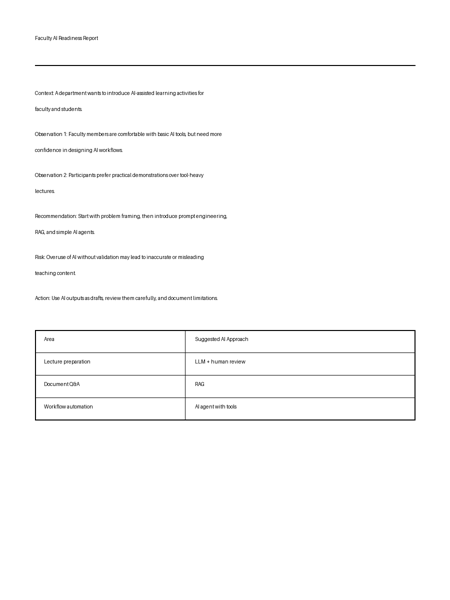

In [8]:
Image.open(report_img_path).resize((450, 600))

# Part A — Vision: Image understanding

### Why this matters

Many enterprise and educational workflows contain visual information:

- Screenshots
- Charts
- Diagrams
- Whiteboard photos
- Scanned forms
- Classroom images

A multimodal model can convert visual information into text, explanation, and action.

In [9]:
image_data_url = image_to_data_url(classroom_img)

question = """
Analyze this image for a faculty development classroom.

Please provide:
1. What is visible in the image?
2. What teaching context does it represent?
3. What could a visually impaired learner miss without alt text?
4. What are the limitations of your interpretation?
"""

answer = call_responses_api(
    model=VISION_MODEL,
    instructions="You are a careful visual-analysis assistant for education use cases. Do not invent details.",
    user_content=[
        {"type": "input_text", "text": question},
        {"type": "input_image", "image_url": image_data_url},
    ],
    max_output_tokens=700,
)

if answer:
    print_box("Vision model response", answer)


Vision model response
### 1. What is visible in the image? The image depicts a classroom setting with a teacher figure
standing in front of a chalkboard. The chalkboard contains text related to an "AI Engineering FDP"
(Faculty Development Program) and mentions topics like "Problem," "Data," "Model," and "Evaluation."
In front of the teacher, there are three student figures, each represented with labels for "Image,"
"Document," and "Audio," indicating different modalities of learning.  ### 2. What teaching context
does it represent? The image represents a faculty development program focused on artificial
intelligence engineering. It suggests a teaching context that emphasizes multimodal learning, where
various forms of content (text, images, and audio) are utilized to enhance understanding and
engagement in the subject matter.  ### 3. What could a visually impaired learner miss without alt
text? Without alt text, a visually impaired learner might miss critical information such as: - Th

# Part B — Prompting changes visual reasoning

The same image can produce different outputs depending on the prompt.

This is a key AI Engineering point:

> The model capability is important, but the problem framing is equally important.

In [10]:
prompts = {
    "Alt text": "Write short alt text for this image for a visually impaired learner.",
    "Teaching use": "Explain how this image can be used to introduce multimodal AI in a faculty workshop.",
    "Risk review": "Identify any possible limitations, risks, or incorrect assumptions that could arise if this image is used as evidence.",
}

for label, prompt in prompts.items():
    print("\n" + "-" * 90)
    print(label)
    print("-" * 90)
    answer = call_responses_api(
        model=VISION_MODEL,
        instructions="You are a concise educational assistant.",
        user_content=[
            {"type": "input_text", "text": prompt},
            {"type": "input_image", "image_url": image_data_url},
        ],
        max_output_tokens=300,
    )
    if answer:
        print(answer)


------------------------------------------------------------------------------------------
Alt text
------------------------------------------------------------------------------------------
A simple illustration showing a presenter with a pointer addressing three seated figures. Above them are labeled boxes for "Image," "Document," and "Audio." The background features a header with "AI Engineering FDP" and topics related to data, model, and evaluation.

------------------------------------------------------------------------------------------
Teaching use
------------------------------------------------------------------------------------------
This image can effectively introduce multimodal AI in a faculty workshop by visually representing key concepts and facilitating discussion. Here’s how:

1. **Visual Engagement**: The diagram captures attention with its simple, clear layout, making it easier for participants to focus on the content.

2. **Conceptual Framework**: It outlines the

# Part C — Chart understanding

Charts are common in reports, dashboards, assessments, and research papers.

A multimodal model can often describe a chart, but we must be careful:

- It may approximate values
- It may miss labels
- It may confuse trends
- Critical decisions should use raw data, not only chart interpretation

In [11]:
chart_data_url = image_to_data_url(chart_img)

chart_prompt = """
Analyze this chart.

Return:
1. The chart title
2. The x-axis categories
3. The approximate highest and lowest values
4. The main insight
5. One caution about using visual chart interpretation
"""

answer = call_responses_api(
    model=VISION_MODEL,
    instructions="You analyze charts carefully. Mention uncertainty when values are approximate.",
    user_content=[
        {"type": "input_text", "text": chart_prompt},
        {"type": "input_image", "image_url": chart_data_url},
    ],
    max_output_tokens=600,
)

if answer:
    print_box("Chart interpretation", answer)


Chart interpretation
1. **Chart Title**: Student Interest by Topic  2. **X-axis Categories**: LLM, Prompting, Vision,
Audio, RAG  3. **Approximate Highest and Lowest Values**:     - Highest Value: ~90    - Lowest
Value: ~60  4. **Main Insight**: The topic "Vision" has the highest student interest score,
indicating it may be the most engaging subject among those listed.  5. **Caution about Using Visual
Chart Interpretation**: Visual representations can sometimes exaggerate differences between values,
leading to misinterpretation of the significance of the data. Always consider the scale and context.


# Part D — Document understanding

Documents are also a multimodal problem when the input is scanned, photographed, or embedded as an image.

Examples:

- Scanned forms
- Handouts
- Reports
- Receipts
- Classroom worksheets
- Policy documents

In production, we often combine OCR, document parsing, RAG, and human review.

In [12]:
report_data_url = image_to_data_url(report_img_path)

document_prompt = """
Read this document image and produce:
1. A short summary
2. Three key points
3. One risk mentioned in the document
4. One recommended action
5. A note on what should be reviewed by a human
"""

answer = call_responses_api(
    model=VISION_MODEL,
    instructions="You are a document-understanding assistant. Extract only what is visible or clearly supported.",
    user_content=[
        {"type": "input_text", "text": document_prompt},
        {"type": "input_image", "image_url": report_data_url},
    ],
    max_output_tokens=700,
)

if answer:
    print_box("Document image understanding", answer)


Document image understanding
### Summary The document outlines the readiness of faculty to incorporate AI-assisted learning
activities, highlighting their comfort with basic AI tools but a need for more confidence in
designing AI workflows. It emphasizes the preference for practical demonstrations and suggests
strategies for effective implementation.  ### Key Points 1. Faculty members are generally
comfortable with basic AI tools but lack confidence in designing AI workflows. 2. There is a
preference for practical demonstrations over tool-heavy lectures among participants. 3.
Recommendations include starting with problem framing and introducing prompt engineering and simple
AI agents.  ### Risk Mentioned Overuse of AI without proper validation may lead to inaccurate or
misleading teaching content.  ### Recommended Action Implement a combination of AI tools with human
review, particularly for lecture preparation.  ### Note for Human Review The suggested approaches
and their effectivene

# Part E — Simple structured output without fragile schemas

Structured output is useful when an application needs fields instead of free text.

For classroom reliability, this notebook uses a simple JSON instruction and local parsing instead of advanced schema parsing.

This avoids version-specific issues while still teaching the core idea.

In [13]:
json_prompt = """
Analyze the image as a teaching artifact.

Return only valid JSON with exactly these keys:
{
  "artifact_type": "string",
  "summary": "string",
  "possible_classroom_use": "string",
  "visible_text": ["string"],
  "uncertainties": ["string"],
  "faculty_review_required": true
}

Rules:
- Return only JSON.
- Use empty lists when there is nothing to list.
- Do not invent text that is not visible.
"""

raw_json_answer = call_responses_api(
    model=VISION_MODEL,
    instructions="You produce valid JSON for educational workflows. Return only JSON, no markdown.",
    user_content=[
        {"type": "input_text", "text": json_prompt},
        {"type": "input_image", "image_url": image_data_url},
    ],
    max_output_tokens=700,
    temperature=0,
)

if raw_json_answer:
    print("Raw model output:\n", raw_json_answer)
    parsed = extract_json(raw_json_answer)
    print("\nParsed JSON object:")
    print(json.dumps(parsed, indent=2))
else:
    parsed = {}

Raw model output:
 {
  "artifact_type": "educational diagram",
  "summary": "The diagram illustrates a teaching scenario in AI Engineering, focusing on data, model evaluation, and multimodal AI involving text, image, and audio.",
  "possible_classroom_use": "This artifact can be used to explain the components of AI Engineering and the importance of multimodal approaches in data evaluation.",
  "visible_text": [
    "AI Engineering FDP",
    "Problem ⊕ Data ⊕ Model ⊕ Evaluation",
    "Multimodal AI: Text + Image + Audio",
    "Image",
    "Document",
    "Audio"
  ],
  "uncertainties": [],
  "faculty_review_required": true
}

Parsed JSON object:
{
  "artifact_type": "educational diagram",
  "summary": "The diagram illustrates a teaching scenario in AI Engineering, focusing on data, model evaluation, and multimodal AI involving text, image, and audio.",
  "possible_classroom_use": "This artifact can be used to explain the components of AI Engineering and the importance of multimodal appr

### AI Engineering note

For production applications, prefer strict structured outputs and validation.  
For teaching beginners, start with the simpler JSON pattern first.

The core lesson is:

> Free-form answers are good for humans. Structured outputs are better for applications.

# Part F — Audio understanding

Audio adds another modality.

Common use cases:

- Lecture transcription
- Meeting notes
- Voice-based assistants
- Accessibility support
- Call center analytics

To keep this notebook reliable, the audio demo is optional. You can record a short `.wav` or `.mp3` file and place it in the `session4_assets` folder.

In [14]:
# Optional audio transcription demo
# Put a file named faculty_question.wav or faculty_question.mp3 inside session4_assets.

RUN_AUDIO_DEMO = False
AUDIO_FILE = ASSET_DIR / "faculty_question.wav"

if RUN_AUDIO_DEMO:
    if client is None:
        print("Skipped audio demo: OPENAI_API_KEY is not configured.")
    elif not AUDIO_FILE.exists():
        print(f"Audio file not found: {AUDIO_FILE}")
        print("Record a short audio question and save it with this name to run the demo.")
    else:
        with AUDIO_FILE.open("rb") as audio_file:
            transcript = client.audio.transcriptions.create(
                model=TRANSCRIBE_MODEL,
                file=audio_file,
            )
        print("Transcript:")
        print(transcript.text)
else:
    print("Audio demo is disabled by default. Set RUN_AUDIO_DEMO = True after adding an audio file.")

Audio demo is disabled by default. Set RUN_AUDIO_DEMO = True after adding an audio file.


# Part G — Video understanding using key frames

Most classroom demos do not need full video processing.

A simple AI Engineering pattern is:

1. Extract important frames from the video
2. Send the frames to the model
3. Ask for sequence-level reasoning
4. Combine with audio transcript if available

In this demo, we simulate three video frames.

In [ ]:
# Create three simple video-like frames
frame_paths = []
steps = [
    ("Frame 1", "Teacher introduces AI problem", "Problem framing"),
    ("Frame 2", "Students inspect image and chart", "Multimodal input"),
    ("Frame 3", "Class discusses limitations", "Human review"),
]

for idx, (title, line1, line2) in enumerate(steps, start=1):
    frame = Image.new("RGB", (800, 450), color=(245, 248, 255))
    dr = ImageDraw.Draw(frame)
    dr.rounded_rectangle((40, 40, 760, 410), radius=20, fill=(230, 240, 255), outline=(50, 90, 180), width=3)
    dr.text((80, 90), title, fill=(20, 40, 90))
    dr.text((80, 180), line1, fill="black")
    dr.text((80, 250), line2, fill=(30, 90, 70))
    path = ASSET_DIR / f"video_frame_{idx}.png"
    frame.save(path)
    frame_paths.append(path)

frame_paths

In [ ]:
# Display the simulated frames
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, path in zip(axes, frame_paths):
    ax.imshow(Image.open(path))
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
video_like_content = [
    {
        "type": "input_text",
        "text": "These three images are key frames from a classroom activity. Explain the sequence and identify the teaching objective.",
    }
]

for path in frame_paths:
    video_like_content.append({"type": "input_image", "image_url": image_to_data_url(path)})

answer = call_responses_api(
    model=VISION_MODEL,
    instructions="You analyze a sequence of images as video key frames. Be concise and avoid inventing events.",
    user_content=video_like_content,
    max_output_tokens=600,
)

if answer:
    print_box("Video key-frame understanding", answer)

# Part H — Multimodal fusion: image + business context

A powerful pattern is to combine:

- A visual artifact
- A text instruction
- A business or teaching context

This is where multimodal AI becomes useful for real workflows.

In [15]:
fusion_prompt = """
You are helping a faculty member prepare a 10-minute classroom discussion.

Use the image and the context below.

Context:
The class has just learned that multimodal AI can process images, documents, audio, video frames, and text together.

Task:
Create a short classroom activity using this image.
Include:
1. Activity title
2. Instructions for students
3. Three discussion questions
4. Expected learning outcome
5. One caution about over-trusting AI outputs
"""

answer = call_responses_api(
    model=VISION_MODEL,
    instructions="You design practical faculty-development classroom activities.",
    user_content=[
        {"type": "input_text", "text": fusion_prompt},
        {"type": "input_image", "image_url": image_data_url},
    ],
    max_output_tokens=800,
)

if answer:
    print_box("Multimodal classroom activity", answer)


Multimodal classroom activity
### Activity Title: Exploring Multimodal AI  #### Instructions for Students: 1. **Group Formation**:
Divide into small groups of 3-4 students. 2. **Image Analysis**: Each group will analyze the
provided image and discuss how multimodal AI can be applied to the elements depicted (text, image,
and audio). 3. **Discussion**: Use the discussion questions below to guide your conversation. Each
group will have 5 minutes to discuss and prepare a brief summary of their thoughts. 4. **Share
Insights**: After the discussion, each group will share their insights with the class for 2-3
minutes.  #### Discussion Questions: 1. How do you think multimodal AI can enhance the understanding
of complex data compared to using a single mode (text, image, or audio)? 2. What are some potential
challenges or limitations of integrating multiple data types in AI models? 3. In what scenarios do
you think relying on multimodal AI could lead to misinterpretations or errors?  #### Exp

# Part I — Mini lab for participants

Choose any one of the following:

### Option 1 — Image activity
Upload or create a simple image related to your teaching subject. Ask the model to generate:

- Description
- Alt text
- Teaching use
- Limitations

### Option 2 — Chart activity
Create a simple chart and ask the model to explain:

- Main insight
- Approximate values
- Possible wrong interpretations

### Option 3 — Document activity
Take a one-page handout or report image and ask the model to extract:

- Summary
- Key points
- Risks
- Human review items

### Reflection question

> Where would multimodal AI genuinely help in your teaching or research workflow?

In [ ]:
# Participant practice cell
# Replace classroom_img with your own local image path.

MY_IMAGE = classroom_img  # Example: Path("my_subject_diagram.png")

practice_prompt = """
Analyze this image for teaching use.
Return:
1. Description
2. Alt text
3. Possible classroom use
4. One limitation
5. One follow-up question for students
"""

answer = call_responses_api(
    model=VISION_MODEL,
    instructions="You are a teaching assistant helping faculty use images responsibly.",
    user_content=[
        {"type": "input_text", "text": practice_prompt},
        {"type": "input_image", "image_url": image_to_data_url(MY_IMAGE)},
    ],
    max_output_tokens=700,
)

if answer:
    print_box("Participant practice result", answer)

# Key takeaways

1. Multimodal AI works with more than text.
2. Images, documents, audio, and video frames can become part of an AI workflow.
3. The same image can produce very different outputs depending on the prompt.
4. Local Base64 image input is more reliable than depending on external URLs.
5. Structured output helps convert AI answers into application-ready data.
6. Multimodal AI is powerful, but it still needs human review.

## Final thought

> Multimodal AI is not just about seeing images.  
> It is about connecting different forms of information to solve a real problem.

## AI Engineering questions to remember

- What is the actual problem?
- Which modality contains the useful signal?
- Can the model interpret it reliably?
- What must be validated by humans?
- What is the risk if the model is wrong?

# Troubleshooting

### 1. `invalid_image_url`
Use local Base64 images instead of external URLs. This notebook already follows that pattern.

### 2. API key not found
Set `OPENAI_API_KEY` as an environment variable or in a `.env` file.

### 3. Model not available
Change `VISION_MODEL` to a model available in your account, for example:

```python
VISION_MODEL = "gpt-4o-mini"
```

### 4. Structured output schema error
This notebook avoids fragile schema parsing for the FDP classroom version. It uses simple JSON output and local parsing.

### 5. Audio file missing
Audio demo is optional. Add your own audio file and set `RUN_AUDIO_DEMO = True`.